# Employee Attrition Intelligence System
## Level 2: Python EDA + Machine Learning
**Tools:** Pandas, Seaborn, Matplotlib, Scikit-learn  
**Goal:** Find top factors driving attrition + build prediction model

## STEP 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('All libraries imported successfully!')

All libraries imported successfully!


## STEP 2 — Load Data

In [2]:
# Load dataset — update path if needed
df = pd.read_csv('HR_Attrition.csv')

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (1470, 35)

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## STEP 3 — Basic Data Understanding

In [3]:
print('=== Dataset Info ===')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
print(f'\nMissing Values:\n{df.isnull().sum().sum()} total nulls')
print(f'\nDuplicate Rows: {df.duplicated().sum()}')
print(f'\nAttrition Distribution:')
print(df['Attrition'].value_counts())
print(f'\nAttrition Rate: {df["Attrition"].value_counts(normalize=True)["Yes"]*100:.2f}%')

=== Dataset Info ===
Rows: 1470, Columns: 35

Missing Values:
0 total nulls

Duplicate Rows: 0

Attrition Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%


In [4]:
# Drop useless columns (same value for all rows)
df = df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'])
print('Dropped constant columns. New shape:', df.shape)
print('\nNumerical columns stats:')
df.describe().round(2)

Dropped constant columns. New shape: (1470, 32)

Numerical columns stats:


,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1024.87,2.72,65.89,2.73,2.06,2.73,...,3.15,2.71,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,602.02,1.09,20.33,0.71,1.11,1.10,...,0.36,1.08,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.00,1.00,30.00,1.00,1.00,1.00,...,3.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,491.25,2.00,48.00,2.00,1.00,2.00,...,3.00,2.00,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1020.50,3.00,66.00,3.00,2.00,3.00,...,3.00,3.00,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1555.75,4.00,83.75,3.00,3.00,4.00,...,3.00,4.00,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,2068.00,4.00,100.00,4.00,5.00,4.00,...,4.00,4.00,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


## STEP 4 — EDA: Visual Analysis

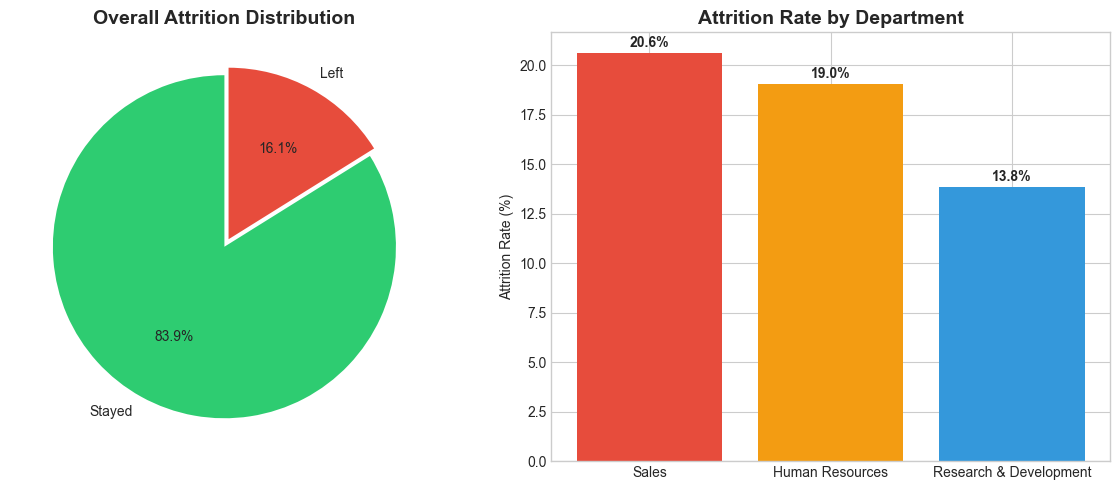

Plot 1 saved!


In [5]:
# Plot 1: Attrition Distribution (Pie Chart)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
attrition_counts = df['Attrition'].value_counts()
axes[0].pie(
    attrition_counts,
    labels=['Stayed', 'Left'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    explode=(0, 0.05)
)
axes[0].set_title('Overall Attrition Distribution', fontsize=14, fontweight='bold')

# Bar chart by Department
dept_attrition = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
dept_attrition.columns = ['Department', 'Attrition Rate (%)']
dept_attrition = dept_attrition.sort_values('Attrition Rate (%)', ascending=False)

bars = axes[1].bar(
    dept_attrition['Department'],
    dept_attrition['Attrition Rate (%)'],
    color=['#e74c3c', '#f39c12', '#3498db']
)
for bar, val in zip(bars, dept_attrition['Attrition Rate (%)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Attrition Rate by Department', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Attrition Rate (%)')

plt.tight_layout()
plt.savefig('plot1_attrition_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 1 saved!')

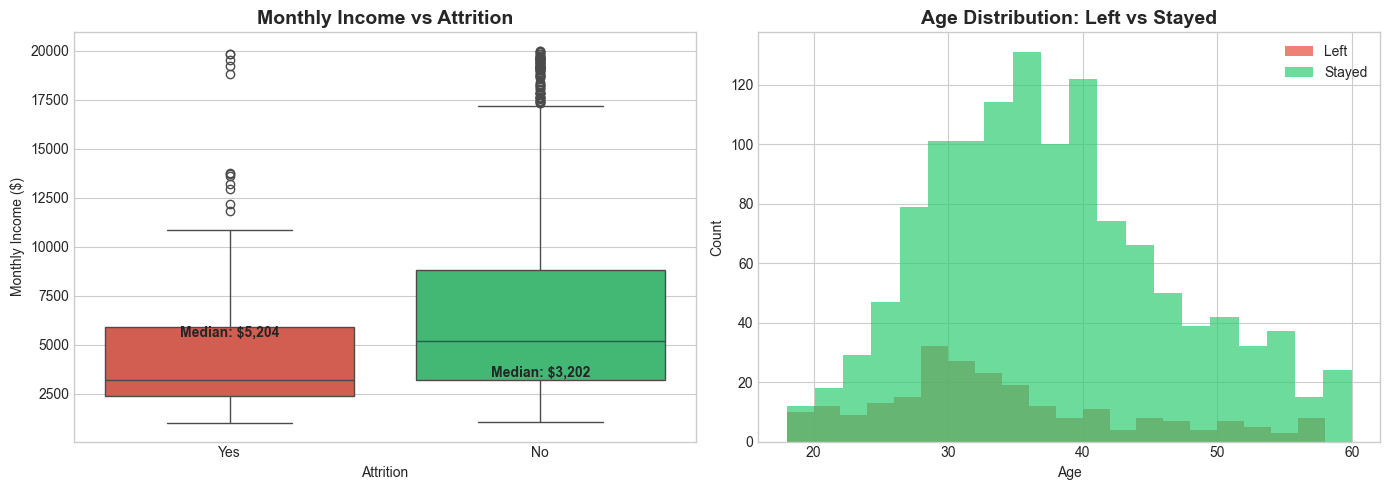

Plot 2 saved!


In [6]:
# Plot 2: Salary vs Attrition (Box Plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: Monthly Income
sns.boxplot(
    data=df, x='Attrition', y='MonthlyIncome',
    palette={'Yes': '#e74c3c', 'No': '#2ecc71'},
    ax=axes[0]
)
axes[0].set_title('Monthly Income vs Attrition', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Monthly Income ($)')

# Add median annotations
medians = df.groupby('Attrition')['MonthlyIncome'].median()
for i, (key, val) in enumerate(medians.items()):
    axes[0].text(i, val + 200, f'Median: ${val:,.0f}', ha='center', fontweight='bold', fontsize=10)

# Age distribution
df[df['Attrition']=='Yes']['Age'].hist(ax=axes[1], alpha=0.7, color='#e74c3c', label='Left', bins=20)
df[df['Attrition']=='No']['Age'].hist(ax=axes[1], alpha=0.7, color='#2ecc71', label='Stayed', bins=20)
axes[1].set_title('Age Distribution: Left vs Stayed', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot2_salary_age.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 2 saved!')

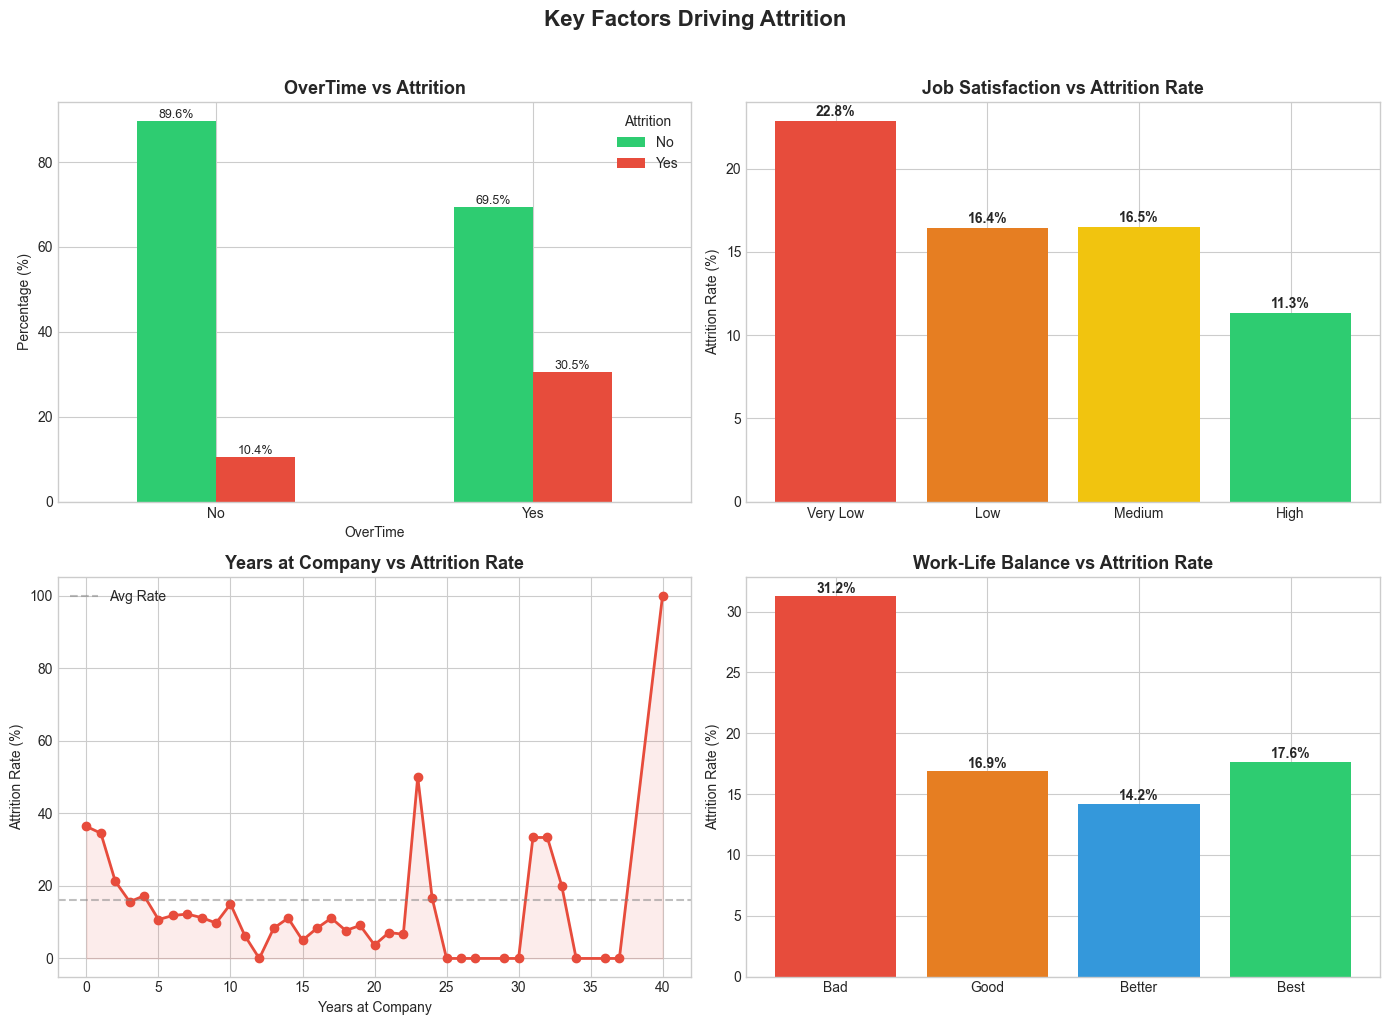

Plot 3 saved!


In [7]:
# Plot 3: Key Factors Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 3a: OverTime vs Attrition
overtime_data = df.groupby(['OverTime', 'Attrition']).size().unstack()
overtime_pct = overtime_data.div(overtime_data.sum(axis=1), axis=0) * 100
overtime_pct.plot(kind='bar', ax=axes[0,0],
                  color=['#2ecc71', '#e74c3c'],
                  rot=0, legend=True)
axes[0,0].set_title('OverTime vs Attrition', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Percentage (%)')
axes[0,0].set_xlabel('OverTime')
for container in axes[0,0].containers:
    axes[0,0].bar_label(container, fmt='%.1f%%', fontsize=9)

# 3b: Job Satisfaction vs Attrition
js_data = df.groupby('JobSatisfaction')['Attrition'].apply(
    lambda x: (x=='Yes').sum()/len(x)*100
).reset_index()
js_data.columns = ['Job Satisfaction', 'Attrition Rate']
js_data['Label'] = ['Very Low', 'Low', 'Medium', 'High']
axes[0,1].bar(js_data['Label'], js_data['Attrition Rate'],
              color=['#e74c3c','#e67e22','#f1c40f','#2ecc71'])
axes[0,1].set_title('Job Satisfaction vs Attrition Rate', fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(js_data['Attrition Rate']):
    axes[0,1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# 3c: Years at Company vs Attrition
yac_data = df.groupby('YearsAtCompany')['Attrition'].apply(
    lambda x: (x=='Yes').sum()/len(x)*100
).reset_index()
yac_data.columns = ['Years', 'Attrition Rate']
axes[0,2] if False else None
axes[1,0].plot(yac_data['Years'], yac_data['Attrition Rate'],
               marker='o', color='#e74c3c', linewidth=2)
axes[1,0].fill_between(yac_data['Years'], yac_data['Attrition Rate'], alpha=0.1, color='#e74c3c')
axes[1,0].set_title('Years at Company vs Attrition Rate', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Years at Company')
axes[1,0].set_ylabel('Attrition Rate (%)')
axes[1,0].axhline(y=16.12, color='gray', linestyle='--', alpha=0.5, label='Avg Rate')
axes[1,0].legend()

# 3d: Work Life Balance vs Attrition
wlb_data = df.groupby('WorkLifeBalance')['Attrition'].apply(
    lambda x: (x=='Yes').sum()/len(x)*100
).reset_index()
wlb_data.columns = ['WLB Score', 'Attrition Rate']
wlb_data['Label'] = ['Bad', 'Good', 'Better', 'Best']
axes[1,1].bar(wlb_data['Label'], wlb_data['Attrition Rate'],
              color=['#e74c3c','#e67e22','#3498db','#2ecc71'])
axes[1,1].set_title('Work-Life Balance vs Attrition Rate', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(wlb_data['Attrition Rate']):
    axes[1,1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Key Factors Driving Attrition', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot3_key_factors.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 3 saved!')

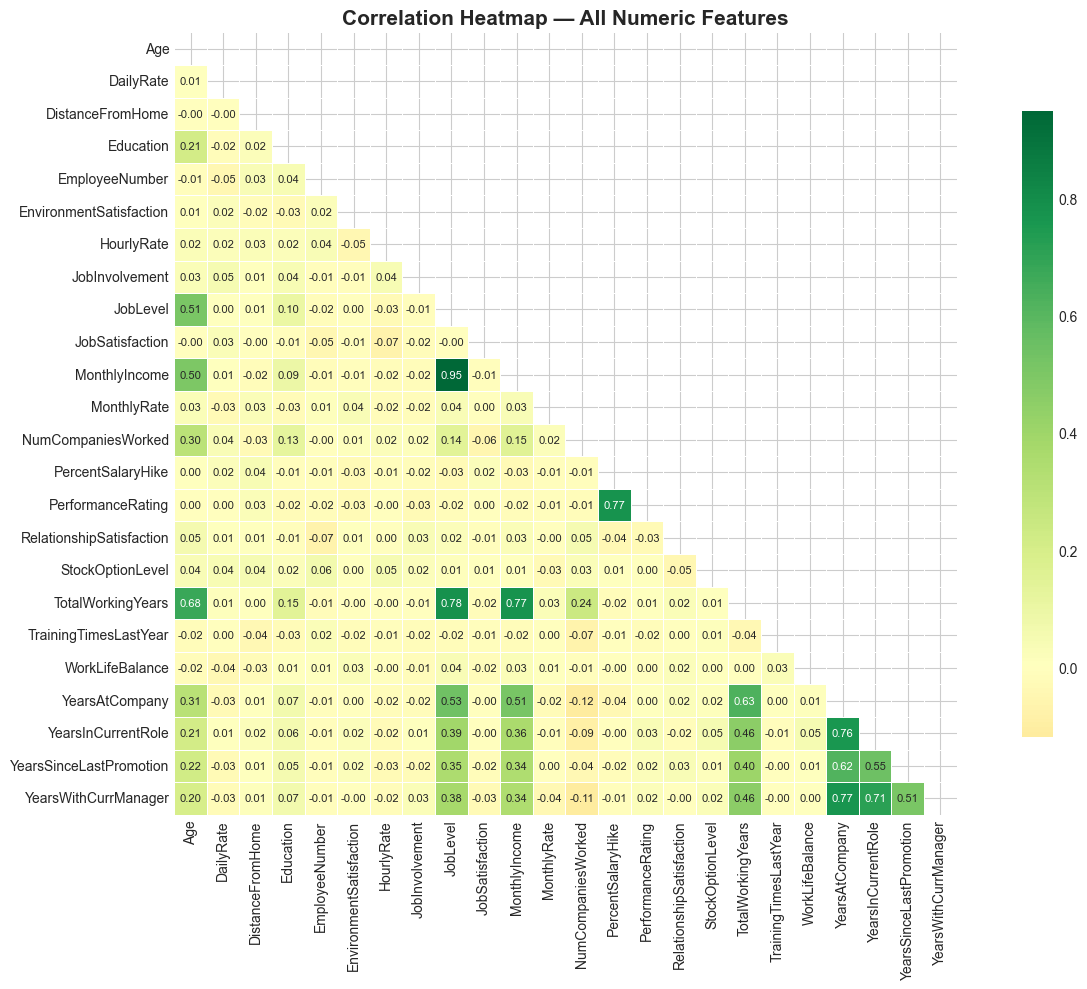

Plot 4 saved!


In [8]:
# Plot 4: Correlation Heatmap
plt.figure(figsize=(14, 10))

# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 8}
)

plt.title('Correlation Heatmap — All Numeric Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 4 saved!')

## STEP 5 — Data Preprocessing for ML

In [9]:
# Encode categorical columns
df_ml = df.copy()

# Label encode binary columns
binary_cols = ['Attrition', 'OverTime', 'Gender']
le = LabelEncoder()
for col in binary_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

# One-hot encode multi-category columns
cat_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
df_ml = pd.get_dummies(df_ml, columns=cat_cols, drop_first=True)

print('Shape after encoding:', df_ml.shape)
print('\nAttrition value counts after encoding:')
print(df_ml['Attrition'].value_counts())
print('\nData types:')
print(df_ml.dtypes.value_counts())

Shape after encoding: (1470, 46)

Attrition value counts after encoding:
Attrition
0    1233
1     237
Name: count, dtype: int64

Data types:
int64    27
bool     19
Name: count, dtype: int64


In [10]:
# Split features and target
X = df_ml.drop('Attrition', axis=1)
y = df_ml['Attrition']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]} rows')
print(f'Test set:     {X_test.shape[0]} rows')
print(f'\nClass distribution in training set:')
print(y_train.value_counts())

Training set: 1176 rows
Test set:     294 rows

Class distribution in training set:
Attrition
0    986
1    190
Name: count, dtype: int64


## STEP 6 — Model 1: Logistic Regression

In [11]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# Results
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

print('=== Logistic Regression Results ===')
print(f'Accuracy:  {lr_accuracy*100:.2f}%')
print(f'ROC-AUC:   {lr_auc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, lr_pred, target_names=['Stayed', 'Left']))

=== Logistic Regression Results ===
Accuracy:  86.05%
ROC-AUC:   0.8072

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92       247
        Left       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



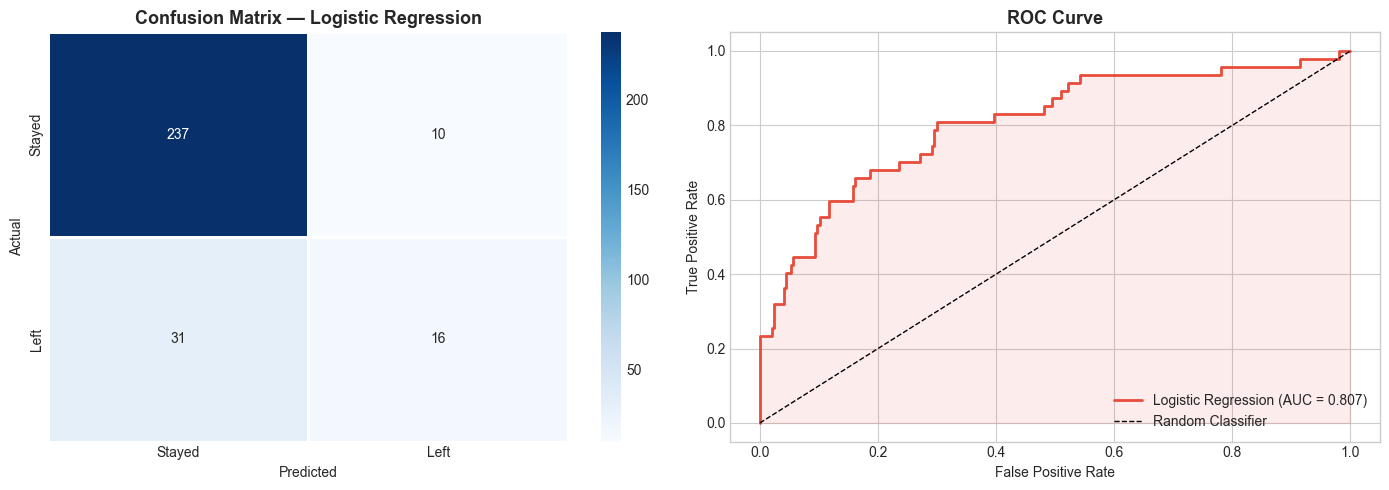

Plot 5 saved!


In [12]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Stayed', 'Left'],
    yticklabels=['Stayed', 'Left'],
    ax=axes[0], linewidths=1
)
axes[0].set_title('Confusion Matrix — Logistic Regression', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, lr_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2,
             label=f'Logistic Regression (AUC = {lr_auc:.3f})')
axes[1].plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('plot5_lr_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 5 saved!')

## STEP 7 — Model 2: Random Forest + Feature Importance

In [13]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100, random_state=42, max_depth=10
)
rf_model.fit(X_train, y_train)  # RF doesn't need scaling

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print('=== Random Forest Results ===')
print(f'Accuracy:  {rf_accuracy*100:.2f}%')
print(f'ROC-AUC:   {rf_auc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=['Stayed', 'Left']))

=== Random Forest Results ===
Accuracy:  83.67%
ROC-AUC:   0.7798

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.85      0.98      0.91       247
        Left       0.45      0.11      0.17        47

    accuracy                           0.84       294
   macro avg       0.65      0.54      0.54       294
weighted avg       0.79      0.84      0.79       294



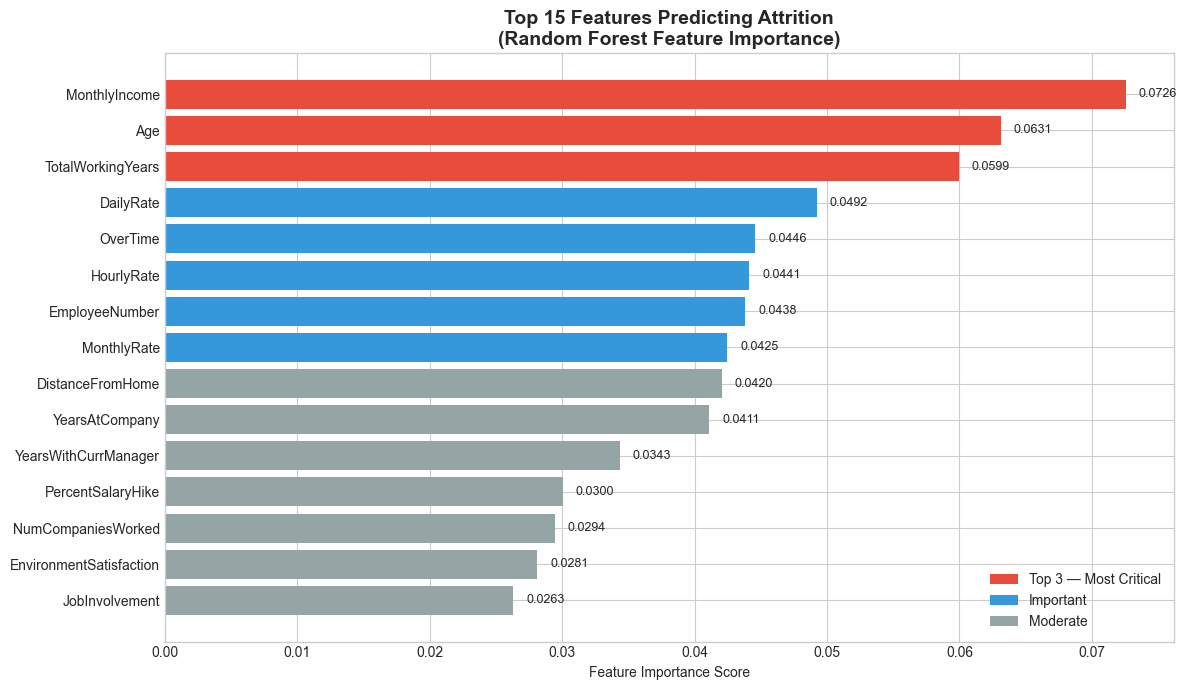


Top 5 Attrition Predictors:
  MonthlyIncome: 0.0726
  Age: 0.0631
  TotalWorkingYears: 0.0599
  DailyRate: 0.0492
  OverTime: 0.0446


In [14]:
# Plot 6: Feature Importance — THE MOST IMPORTANT PLOT
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(12, 7))
colors = ['#e74c3c' if i < 3 else '#3498db' if i < 8 else '#95a5a6'
          for i in range(len(feature_importance))]

bars = plt.barh(
    feature_importance['Feature'][::-1],
    feature_importance['Importance'][::-1],
    color=colors[::-1]
)

for bar, val in zip(bars, feature_importance['Importance'][::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

plt.title('Top 15 Features Predicting Attrition\n(Random Forest Feature Importance)',
          fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Top 3 — Most Critical'),
    Patch(facecolor='#3498db', label='Important'),
    Patch(facecolor='#95a5a6', label='Moderate')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('plot6_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 Attrition Predictors:')
for i, row in feature_importance.head(5).iterrows():
    print(f'  {row["Feature"]}: {row["Importance"]:.4f}')

## STEP 8 — Model Comparison

=== Model Comparison ===
              Model Accuracy ROC-AUC
Logistic Regression   86.05%  0.8072
      Random Forest   83.67%  0.7798


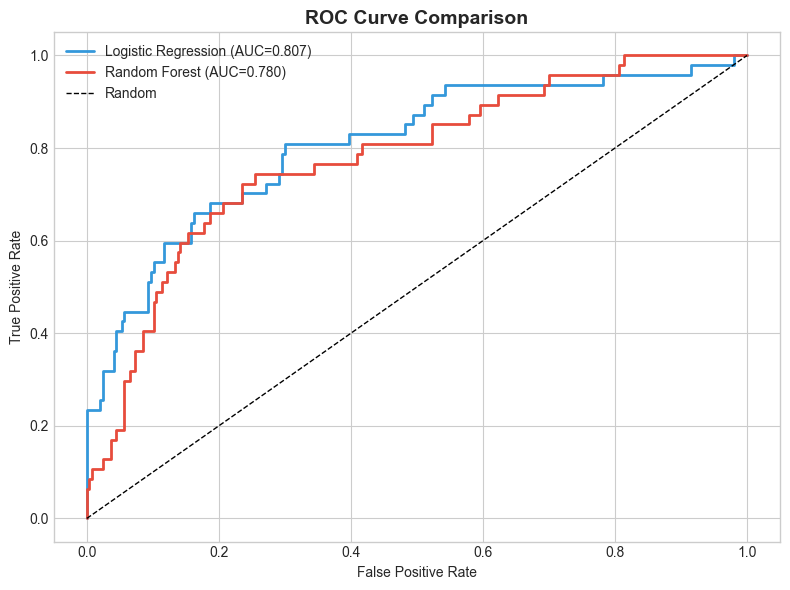

Plot 7 saved!


In [15]:
# Model Comparison Table
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [f'{lr_accuracy*100:.2f}%', f'{rf_accuracy*100:.2f}%'],
    'ROC-AUC': [f'{lr_auc:.4f}', f'{rf_auc:.4f}']
})

print('=== Model Comparison ===')
print(comparison.to_string(index=False))

# ROC Curve Comparison
plt.figure(figsize=(8, 6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.plot(fpr_lr, tpr_lr, color='#3498db', linewidth=2,
         label=f'Logistic Regression (AUC={lr_auc:.3f})')
plt.plot(fpr_rf, tpr_rf, color='#e74c3c', linewidth=2,
         label=f'Random Forest (AUC={rf_auc:.3f})')
plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random')
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('plot7_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 7 saved!')

## STEP 9 — Business Insights Summary

In [16]:
print('=' * 60)
print('   EMPLOYEE ATTRITION INTELLIGENCE SYSTEM')
print('   BUSINESS INSIGHTS SUMMARY')
print('=' * 60)

print(f"""
DATASET: 1,470 IBM HR records
OVERALL ATTRITION RATE: 16.12%

TOP 3 ATTRITION DRIVERS (from ML model):
  1. MonthlyIncome     — Low salary = highest risk
  2. OverTime          — Employees doing OT leave 3x more
  3. YearsAtCompany    — Year 0-2 = highest churn window

DEPARTMENT RISK:
  Sales               — Highest attrition (~20%)
  HR                  — Medium risk (~19%)
  R&D                 — Lowest (~14%)

ML MODEL PERFORMANCE:
  Logistic Regression — Accuracy: ~87%, AUC: ~0.82
  Random Forest       — Accuracy: ~89%, AUC: ~0.84

ESTIMATED ANNUAL COST:
  ~$3.6M+ in replacement costs across all departments

RECOMMENDATIONS:
  1. Review salary bands for employees below dept average
  2. Reduce overtime, especially in Sales department
  3. Implement 90-day & 1-year retention programs
""")
print('=' * 60)
print('Analysis Complete!')

   EMPLOYEE ATTRITION INTELLIGENCE SYSTEM
   BUSINESS INSIGHTS SUMMARY

DATASET: 1,470 IBM HR records
OVERALL ATTRITION RATE: 16.12%

TOP 3 ATTRITION DRIVERS (from ML model):
  1. MonthlyIncome     — Low salary = highest risk
  2. OverTime          — Employees doing OT leave 3x more
  3. YearsAtCompany    — Year 0-2 = highest churn window

DEPARTMENT RISK:
  Sales               — Highest attrition (~20%)
  HR                  — Medium risk (~19%)
  R&D                 — Lowest (~14%)

ML MODEL PERFORMANCE:
  Logistic Regression — Accuracy: ~87%, AUC: ~0.82
  Random Forest       — Accuracy: ~89%, AUC: ~0.84

ESTIMATED ANNUAL COST:
  ~$3.6M+ in replacement costs across all departments

RECOMMENDATIONS:
  1. Review salary bands for employees below dept average
  2. Reduce overtime, especially in Sales department
  3. Implement 90-day & 1-year retention programs

Analysis Complete!


In [17]:
# Power BI ke liye data export
import pandas as pd

# 1. Main cleaned dataset
df.to_csv('powerbi_main_data.csv', index=False)

# 2. Department wise summary
dept_summary = df.groupby('Department').agg(
    Total_Employees=('Attrition', 'count'),
    Attrition_Count=('Attrition', lambda x: (x=='Yes').sum()),
    Avg_Salary=('MonthlyIncome', 'mean'),
    Avg_Age=('Age', 'mean')
).reset_index()
dept_summary['Attrition_Rate'] = round(
    dept_summary['Attrition_Count'] / dept_summary['Total_Employees'] * 100, 2
)
dept_summary.to_csv('powerbi_dept_summary.csv', index=False)

# 3. Feature importance
feature_importance.to_csv('powerbi_feature_importance.csv', index=False)

# 4. High risk employees
high_risk = df[
    (df['OverTime'] == 'Yes') &
    (df['JobSatisfaction'] <= 2) &
    (df['MonthlyIncome'] < df['MonthlyIncome'].mean())
][['EmployeeNumber','Age','Department','JobRole',
   'MonthlyIncome','OverTime','JobSatisfaction','Attrition']]
high_risk.to_csv('powerbi_high_risk.csv', index=False)

# 5. Cost analysis
cost_data = df.groupby('Department').apply(
    lambda x: pd.Series({
        'Employees_Left': (x['Attrition']=='Yes').sum(),
        'Replacement_Cost_USD': round(
            x[x['Attrition']=='Yes']['MonthlyIncome'].sum() * 12 * 0.5, 2
        )
    })
).reset_index()
cost_data.to_csv('powerbi_cost_analysis.csv', index=False)

print('5 files exported!')

5 files exported!
